In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

In [4]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [5]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [6]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [7]:
cagr_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max() -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    cagr_results.append(
        [code, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

In [8]:
cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [9]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    mean_return = (
        temp["daily_return"]
        .mean()
    )

    std_return = (
        temp["daily_return"]
        .std()
    )

    sharpe = (
        (mean_return - rf/252)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

In [10]:
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [11]:
sortino_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    downside = temp[
        temp["daily_return"] < 0
    ]["daily_return"]

    downside_std = downside.std()

    mean_return = (
        temp["daily_return"]
        .mean()
    )

    sortino = (
        (mean_return - rf/252)
        / downside_std
    ) * np.sqrt(252)

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [12]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [13]:
dd_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    running_max = (
        temp["nav"]
        .cummax()
    )

    drawdown = (
        temp["nav"] /
        running_max
    ) - 1

    dd_results.append(
        [
            code,
            drawdown.min()
        ]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [14]:
dd_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


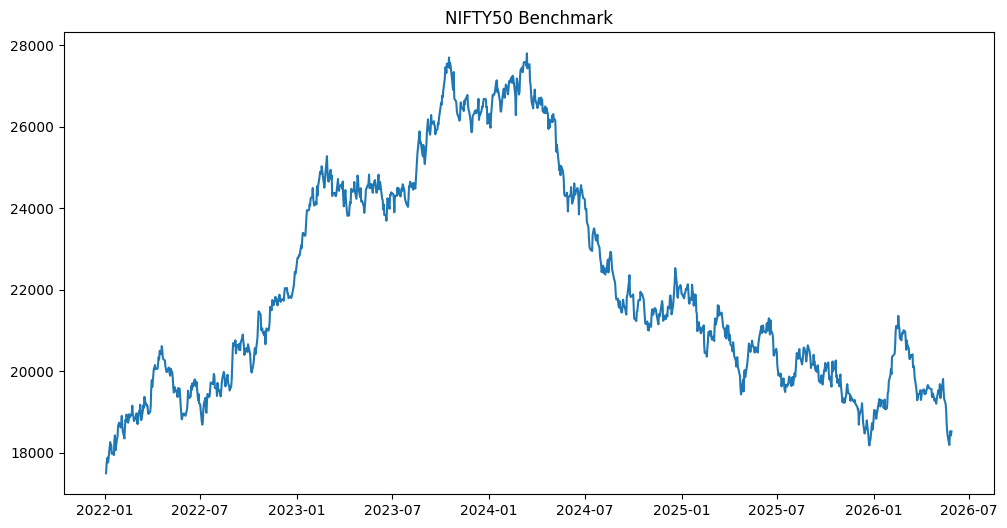

In [15]:
nifty50 = benchmark[
    benchmark["index_name"]
    == "NIFTY50"
]

plt.figure(
    figsize=(12,6)
)

plt.plot(
    nifty50["date"],
    nifty50["close_value"]
)

plt.title(
    "NIFTY50 Benchmark"
)

plt.show()

In [16]:
cagr_df.to_csv(
    "../reports/cagr_results.csv",
    index=False
)

sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

sortino_df.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

dd_df.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [17]:
nifty = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)

alpha_beta_results = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 30:

        slope, intercept, r, p, std = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta_results.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


In [18]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [19]:
scorecard = pd.merge(
    cagr_df,
    sharpe_df,
    on="amfi_code"
)

scorecard = pd.merge(
    scorecard,
    alpha_beta_df,
    on="amfi_code"
)

scorecard = pd.merge(
    scorecard,
    dd_df,
    on="amfi_code"
)

scorecard = pd.merge(
    scorecard,
    performance[
        ["amfi_code",
         "expense_ratio_pct"]
    ],
    on="amfi_code"
)

In [20]:
scorecard["return_rank"] = scorecard[
    "cagr"
].rank(pct=True)

scorecard["sharpe_rank"] = scorecard[
    "sharpe_ratio"
].rank(pct=True)

scorecard["alpha_rank"] = scorecard[
    "alpha"
].rank(pct=True)

scorecard["expense_rank"] = (
    1 -
    scorecard[
        "expense_ratio_pct"
    ].rank(pct=True)
)

scorecard["dd_rank"] = (
    1 -
    scorecard[
        "max_drawdown"
    ].rank(pct=True)
)

scorecard["fund_score"] = (
    scorecard["return_rank"] * 30 +
    scorecard["sharpe_rank"] * 25 +
    scorecard["alpha_rank"] * 20 +
    scorecard["expense_rank"] * 15 +
    scorecard["dd_rank"] * 10
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,0.328016,1.180101,0.293014,-0.017391,-0.181885,1.36,1.000,0.900,0.950,0.6250,0.600,86.8750
21,119598,0.323981,0.945308,0.301114,0.074266,-0.287060,1.43,0.975,0.675,1.000,0.4750,0.875,82.0000
39,149324,0.322621,0.949796,0.298179,0.132608,-0.311719,1.52,0.950,0.700,0.975,0.3375,0.900,79.5625
30,120843,0.308833,1.306744,0.272784,-0.008737,-0.129740,1.45,0.875,0.975,0.900,0.4500,0.300,78.3750
2,100033,0.300997,1.093699,0.272343,-0.011200,-0.162172,1.38,0.850,0.850,0.875,0.5750,0.475,77.6250


In [21]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

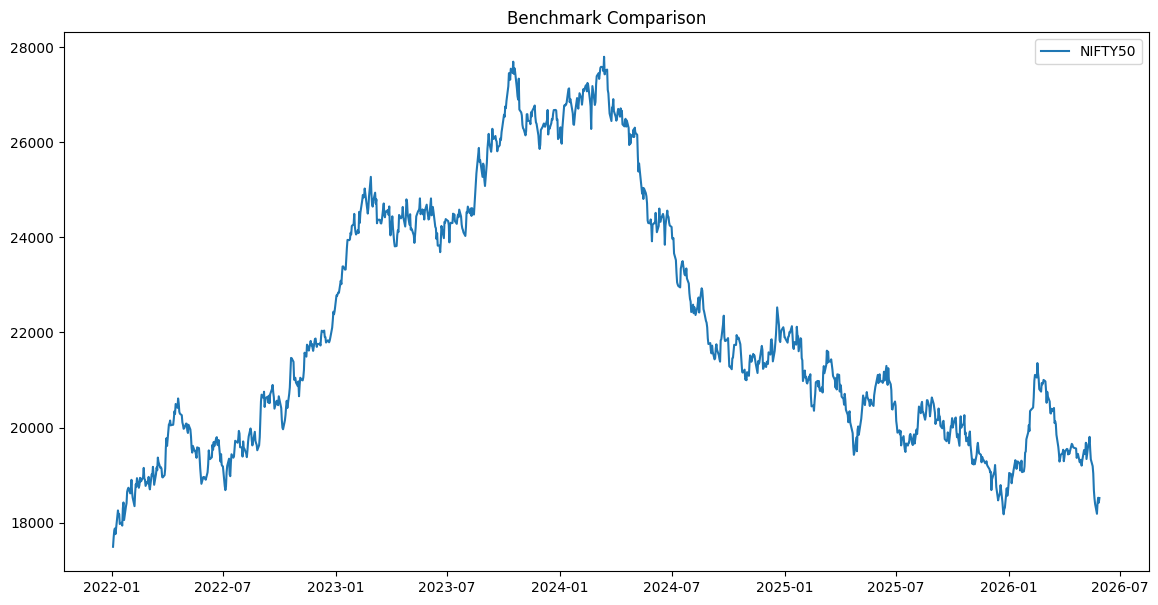

In [22]:
plt.figure(figsize=(14,7))

plt.plot(
    nifty["date"],
    nifty["close_value"],
    label="NIFTY50"
)

plt.legend()

plt.title(
    "Benchmark Comparison"
)

plt.show()

In [23]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>